# Sprint 1 — Bus GTFS Spatial EDA (Victoria)

**Stream:** Team A — Cycling / Public Transport / Pedestrian mode shift &nbsp;·&nbsp; **Subgroup:** Bus
**Branch:** `feature/rd/teamA-bus`

**Dataset:** PTV GTFS Schedule — Transport Victoria Open Data (CC BY 4.0)
**Bus feeds:** `4` Myki Bus → *Metropolitan bus* · `5` Regional Coach → *V/Line coach* · `6` Regional Bus → *Regional bus*

Spatial companion to `00_bus_patronage_eda.ipynb`. Loads the Victorian GTFS schedule, links **routes → trips → stop_times → stops**, and profiles the bus **network**: route/stop coverage, a stop map, service timing, data quality, and a CRS reprojection to Vicgrid for distance-based metrics.

---
### ⚠️ Coverage caveat
The GTFS Schedule is a **rolling ~30-day snapshot of the *current* network**, not a historical archive. It answers *where the bus network is today* (stops, routes, timetabled service) — it **cannot** provide pre-intervention timetables. Historical before/after service levels would need archived GTFS snapshots (e.g. the Mobility Database). This complements the statewide patronage series in `00`.

### CRS
Stops are published in **WGS84 (EPSG:4326)**. Any distance/spacing metric is computed after reprojecting to the projected **Vicgrid 2020 (EPSG:7899)**, per the repo's CRS rule.

### Data source & reproducibility
`data/raw/` is git-ignored. Reproduce the inputs by downloading `gtfs.zip` from Transport Victoria Open Data into `data/raw/`, then extracting mode folders 4/5/6 into `data/raw/gtfs/{metro_bus, regional_coach, regional_bus}/` (each holds the standard GTFS `.txt` files).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.spatial import cKDTree

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

WGS84 = "EPSG:4326"      # geographic (lat/lon), as published
VICGRID = "EPSG:7899"    # projected (metres), for distance metrics

# GTFS bus feeds -> friendly mode label (matches the patronage modes in notebook 00).
BUS_FEEDS = {
    "metro_bus": "Metropolitan bus",
    "regional_coach": "V/Line coach",
    "regional_bus": "Regional bus",
}
MODE_COLORS = {"Metropolitan bus": "tab:blue", "V/Line coach": "tab:red", "Regional bus": "tab:green"}


def find_project_root(marker: str = "config.yaml") -> Path:
    """Locate the repo root by walking up from the working directory until ``marker`` is found."""
    base = Path.cwd().resolve()
    for parent in [base, *base.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not locate project root above {base}.")


PROJECT_ROOT = find_project_root()
GTFS_DIR = PROJECT_ROOT / "data" / "raw" / "gtfs"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

if not GTFS_DIR.exists():
    raise FileNotFoundError(
        f"Expected extracted GTFS bus feeds under {GTFS_DIR}.\n"
        "Download gtfs.zip into data/raw/ and extract mode folders 4/5/6 into "
        "data/raw/gtfs/{metro_bus, regional_coach, regional_bus}/ (see the first markdown cell)."
    )

print("Project root:", PROJECT_ROOT.name)
print("GTFS feeds  :", [d.name for d in sorted(GTFS_DIR.iterdir()) if d.is_dir()])

Project root: Victoria-Urban-Planning
GTFS feeds  : ['metro_bus', 'regional_bus', 'regional_coach']


## Step 1 — Load & link the feeds

Read `routes`, `trips`, and `stops` for each bus feed, tag every row with its mode, and combine. The GTFS relational keys are `route_id` (routes↔trips), `trip_id` (trips↔stop_times), and `stop_id` (stop_times↔stops).

In [2]:
def load_gtfs(feed: str, fname: str, usecols=None) -> pd.DataFrame:
    """Read one GTFS text file for a feed as strings (GTFS ids are strings), tagged with its mode."""
    df = pd.read_csv(GTFS_DIR / feed / fname, dtype=str, encoding="utf-8-sig",
                     usecols=usecols, low_memory=False)
    df["mode"] = BUS_FEEDS[feed]
    return df


routes = pd.concat([load_gtfs(f, "routes.txt") for f in BUS_FEEDS], ignore_index=True)
trips = pd.concat([load_gtfs(f, "trips.txt") for f in BUS_FEEDS], ignore_index=True)
stops = pd.concat([load_gtfs(f, "stops.txt") for f in BUS_FEEDS], ignore_index=True)

# Numeric coordinates for the spatial work.
stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")

overview = pd.DataFrame({
    "routes": routes.groupby("mode").size(),
    "trips": trips.groupby("mode").size(),
    "stops": stops.groupby("mode").size(),
}).reindex(list(BUS_FEEDS.values()))
overview.loc["TOTAL"] = overview.sum()
print("=== Bus network coverage (current GTFS snapshot) ===")
display(overview)

=== Bus network coverage (current GTFS snapshot) ===


,routes,trips,stops
mode,,,
Metropolitan bus,733,176131,22569
V/Line coach,52,6684,866
Regional bus,206,3999,3324
TOTAL,991,186814,26759


## Step 2 — Route composition & service intensity

GTFS `route_type` (extended types) and the number of trips per route in the snapshot. More trips = more timetabled service.

In [3]:
ROUTE_TYPE_LABELS = {
    "3": "Bus (standard)",
    "200": "Coach", "204": "Coach (local)",
    "700": "Bus service", "701": "Bus service", "702": "Express bus",
    "704": "Local bus", "712": "School bus",
}
routes["route_type_label"] = (routes["route_type"].map(ROUTE_TYPE_LABELS)
                              .fillna("route_type " + routes["route_type"].astype(str)))
print("=== Route types by mode ===")
display(routes.groupby(["mode", "route_type_label"]).size().rename("routes").reset_index())

# Trips per route (service intensity).
trips_per_route = trips.groupby(["mode", "route_id"]).size().rename("n_trips").reset_index()
print("\n=== Trips per route (summary by mode) ===")
display(trips_per_route.groupby("mode")["n_trips"].describe()[["count", "mean", "50%", "max"]])

# Busiest routes as an example.
busiest = (trips_per_route
           .merge(routes[["route_id", "mode", "route_short_name", "route_long_name"]], on=["route_id", "mode"])
           .sort_values("n_trips", ascending=False).head(10))
print("\n=== Top 10 routes by scheduled trips ===")
display(busiest[["mode", "route_short_name", "route_long_name", "n_trips"]])

=== Route types by mode ===


,mode,route_type_label,routes
0,Metropolitan bus,Bus (standard),534
1,Metropolitan bus,Bus service,199
2,Regional bus,Bus service,206
3,V/Line coach,Coach (local),52



=== Trips per route (summary by mode) ===


,count,mean,50%,max
mode,,,,
Metropolitan bus,712.0,247.375000,156.5,2456.0
Regional bus,206.0,19.412621,10.0,173.0
V/Line coach,52.0,128.538462,101.5,440.0



=== Top 10 routes by scheduled trips ===


,mode,route_short_name,route_long_name,n_trips
35,Metropolitan bus,246,Elsternwick - Clifton Hill,2456
27,Metropolitan bus,907,Mitcham - City (King/Lonsdale Sts),2105
261,Metropolitan bus,216,Sunshine Station - City (Queen St),1990
262,Metropolitan bus,220,Sunshine Station - City (Queen St),1982
25,Metropolitan bus,905,The Pines SC - City (King/Lonsdale Sts),1791
263,Metropolitan bus,223,Yarraville - Highpoint SC,1710
26,Metropolitan bus,906,Warrandyte - City (King/Lonsdale Sts),1656
28,Metropolitan bus,908,The Pines SC - City (King/Lonsdale Sts),1634
32,Metropolitan bus,235,Fishermans Bend - City (Southern Cross Station),1608
118,Metropolitan bus,732,Upper Ferntree Gully - Box Hill Station,1562


## Step 3 — Spatial view: bus stops across Victoria

Build a GeoDataFrame of stops in WGS84 and map them by mode. Metropolitan-bus stops cluster in Melbourne; coach and regional-bus stops thread out along regional corridors (some V/Line coach stops sit interstate — see Step 6).

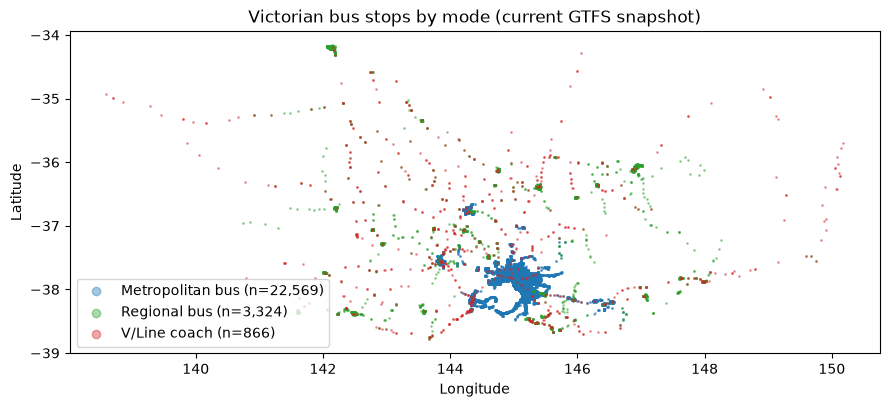

In [4]:
gdf_stops = gpd.GeoDataFrame(
    stops.copy(),
    geometry=gpd.points_from_xy(stops["stop_lon"], stops["stop_lat"]),
    crs=WGS84,
)

fig, ax = plt.subplots(figsize=(9, 9))
for mode, sub in gdf_stops.groupby("mode"):
    sub.plot(ax=ax, markersize=1, alpha=0.4, color=MODE_COLORS.get(mode, "gray"),
             label=f"{mode} (n={len(sub):,})")
ax.set_title("Victorian bus stops by mode (current GTFS snapshot)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=6, loc="lower left")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Step 4 — CRS reprojection & stop spacing (metres)

Distances are meaningless in lat/lon degrees, so reproject stops to **Vicgrid 2020 (EPSG:7899)** and measure the nearest-neighbour distance between stops within each mode — a compact indicator of how dense the stop network is.

In [5]:
gdf_proj = gdf_stops.to_crs(VICGRID)
gdf_proj["x"] = gdf_proj.geometry.x
gdf_proj["y"] = gdf_proj.geometry.y

spacing_rows = []
for mode, sub in gdf_proj.groupby("mode"):
    xy = sub[["x", "y"]].to_numpy()
    if len(xy) < 2:
        continue
    dist, _ = cKDTree(xy).query(xy, k=2)     # k=1 is the point itself
    nn = dist[:, 1]
    spacing_rows.append({
        "mode": mode,
        "stops": len(xy),
        "median_nn_spacing_m": round(float(np.median(nn))),
        "mean_nn_spacing_m": round(float(np.mean(nn))),
    })
spacing = pd.DataFrame(spacing_rows).set_index("mode")
print("=== Nearest-neighbour stop spacing (Vicgrid EPSG:7899, metres) ===")
display(spacing)

=== Nearest-neighbour stop spacing (Vicgrid EPSG:7899, metres) ===


,stops,median_nn_spacing_m,mean_nn_spacing_m
mode,,,
Metropolitan bus,22569,34,66
Regional bus,3324,113,601
V/Line coach,866,61,3002


## Step 5 — Service timing (departures by hour)

`stop_times` is large (~7.4M rows, dominated by metropolitan bus), so we read only `departure_time` per feed to profile when service runs. GTFS allows hours ≥ 24 for after-midnight trips; those are folded back with `% 24`.

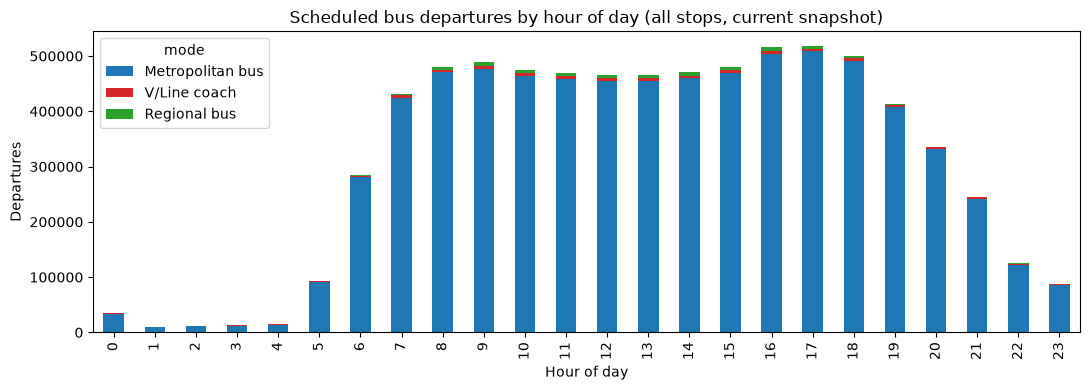

Total scheduled stop-departures in snapshot: 7,430,275


In [6]:
hourly = {}
for feed, label in BUS_FEEDS.items():
    dep = pd.read_csv(GTFS_DIR / feed / "stop_times.txt", usecols=["departure_time"],
                      dtype=str, encoding="utf-8-sig")["departure_time"].dropna()
    hours = (pd.to_numeric(dep.str.slice(0, 2), errors="coerce").dropna().astype(int) % 24)
    hourly[label] = hours.value_counts().reindex(range(24), fill_value=0).sort_index()

hourly_df = pd.DataFrame(hourly).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(11, 4))
hourly_df.plot(kind="bar", stacked=True, ax=ax,
               color=[MODE_COLORS.get(m, "gray") for m in hourly_df.columns])
ax.set_title("Scheduled bus departures by hour of day (all stops, current snapshot)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Departures")
ax.legend(title="mode")
plt.tight_layout()
plt.show()

print("Total scheduled stop-departures in snapshot:", f"{int(hourly_df.values.sum()):,}")

## Step 6 — Data quality

Missing coordinates, duplicate `stop_id`s (within a feed), `location_type` breakdown (0 = stop/platform, 1 = station, 2 = entrance…), and stops falling outside a Victoria bounding box.

In [7]:
from pprint import pprint

# Victoria bounding box (approx). Coach/regional services legitimately cross state borders.
VIC_LON = (140.9, 150.0)
VIC_LAT = (-39.2, -34.0)

quality = {}
quality["missing_coords"] = int(stops["stop_lat"].isna().sum() + stops["stop_lon"].isna().sum())
quality["duplicate_stop_id_within_feed"] = int(stops.duplicated(subset=["mode", "stop_id"]).sum())
quality["location_type_counts"] = stops["location_type"].fillna("0").replace("", "0").value_counts().to_dict()

outside = stops[~(stops["stop_lon"].between(*VIC_LON) & stops["stop_lat"].between(*VIC_LAT))]
quality["stops_outside_vic_bbox"] = {m: int(c) for m, c in outside.groupby("mode").size().items()}

pprint(quality)
print("\nNote: stops outside the VIC bbox are almost all V/Line coach / regional services to "
      "border towns interstate - expected, not an error.")

{'duplicate_stop_id_within_feed': 0,
 'location_type_counts': {'0': 26757, '1': 2},
 'missing_coords': 0,
 'stops_outside_vic_bbox': {'Regional bus': 2, 'V/Line coach': 29}}

Note: stops outside the VIC bbox are almost all V/Line coach / regional services to border towns interstate - expected, not an error.


## Data-engineering output — tidy stop & route tables

Persist clean stop and route tables to `data/processed/` (git-ignored) for downstream corridor analysis: a bus-stops table (mode + coordinates) and a routes table with trip counts.

In [8]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

stops_out = stops[["mode", "stop_id", "stop_name", "stop_lat", "stop_lon", "location_type"]].copy()
stops_out.to_csv(PROCESSED_DIR / "bus_stops.csv", index=False)

routes_out = (routes[["mode", "route_id", "route_short_name", "route_long_name", "route_type", "route_type_label"]]
              .merge(trips_per_route, on=["mode", "route_id"], how="left"))
routes_out["n_trips"] = routes_out["n_trips"].fillna(0).astype(int)
routes_out.to_csv(PROCESSED_DIR / "bus_routes.csv", index=False)

print(f"Wrote {len(stops_out):,} stops  -> data/processed/bus_stops.csv")
print(f"Wrote {len(routes_out):,} routes -> data/processed/bus_routes.csv")

Wrote 26,759 stops  -> data/processed/bus_stops.csv
Wrote 991 routes -> data/processed/bus_routes.csv


## Findings, caveats & next steps

**Network coverage**
- Current snapshot: roughly ~990 bus routes, ~187k scheduled trips and ~26.8k stops across the three feeds (see the coverage table). Metropolitan bus dominates on every measure.
- Service peaks in the AM and PM commuter windows (Step 5), overwhelmingly metropolitan bus.

**Spatial / provenance**
- Metro-bus stops concentrate in Melbourne; coach and regional-bus stops trace regional corridors. Feed `4` ("Myki Bus") mixes metropolitan *and* regional-town buses, so it is not a pure 1:1 with the patronage "Metropolitan bus" line — note this when joining to notebook `00`.
- Some V/Line coach and regional-bus stops sit interstate (border services); flagged in Step 6 as expected, not errors.

**Data quality**
- No missing coordinates and no duplicate `stop_id`s within a feed. `location_type` is mostly stops/platforms.
- A physical stop shared across feeds may appear under different `stop_id`s; de-duplicate on coordinates if a single physical-stop count is needed.

**Coverage limit** — this is a 30-day *current* snapshot; on its own it cannot measure pre-/post-intervention service change (that needs archived GTFS around the intervention dates).

**Next steps (toward the research question)**
- Buffer intervention corridors (~20 m, per `config.yaml`) and select the bus stops/routes within them (`data/processed/bus_stops.csv`) to move from statewide context (notebook `00`) toward corridor-level before/after.
- Source archived GTFS snapshots where before/after *service* change (not just stop presence) matters.